# LLM Inference Analysis

This notebook loads `results.json`, reshapes the benchmark data, and generates plots for prompt processing, token generation, thread scaling, and a TTFT proxy based on the measured timings.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
DATA_PATH = Path("../data/results.json")

In [2]:
with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

phase_records = []
run_records = []

for model in raw["models"]:
    for run_index, run in enumerate(model["runs"], start=1):
        meta = run["metadata"]
        prompt = run["results"]["prompt_processing"]
        generation = run["results"]["token_generation"]

        run_records.append({
            "model": model["name"],
            "run_index": run_index,
            "backend": meta.get("backend"),
            "threads": meta.get("threads"),
            "quantization": meta.get("quantization"),
            "repeats": meta.get("repeats", 1),
            "model_size_gib": meta.get("model_size_gib"),
            "model_size_mib": meta.get("model_size_mib"),
            "parameters_billions": meta.get("parameters_billions"),
            "parameters_millions": meta.get("parameters_millions"),
            "prompt_tokens": prompt["tokens"],
            "prompt_tps": prompt["tokens_per_second"],
            "prompt_stddev": prompt["stddev"],
            "prompt_seconds": prompt["tokens"] / prompt["tokens_per_second"],
            "generation_tokens": generation["tokens"],
            "generation_tps": generation["tokens_per_second"],
            "generation_stddev": generation["stddev"],
            "generation_seconds": generation["tokens"] / generation["tokens_per_second"],
            "ttft_proxy_seconds": (prompt["tokens"] / prompt["tokens_per_second"]) + (generation["tokens"] / generation["tokens_per_second"]) if generation["tokens"] == 1 else np.nan,
        })

        for phase_key, phase_label, phase in [
            ("prompt_processing", "Prompt", prompt),
            ("token_generation", "Generation", generation),
        ]:
            phase_records.append({
                "model": model["name"],
                "run_index": run_index,
                "phase_key": phase_key,
                "phase": phase_label,
                "backend": meta.get("backend"),
                "threads": meta.get("threads"),
                "quantization": meta.get("quantization"),
                "repeats": meta.get("repeats", 1),
                "tokens": phase["tokens"],
                "tokens_per_second": phase["tokens_per_second"],
                "stddev": phase["stddev"],
                "phase_seconds": phase["tokens"] / phase["tokens_per_second"],
            })

phase_df = pd.DataFrame(phase_records)
run_df = pd.DataFrame(run_records)

display(run_df.head())
print(f"Loaded {len(run_df)} runs across {run_df['model'].nunique()} models.")

,model,run_index,backend,threads,quantization,repeats,model_size_gib,model_size_mib,parameters_billions,parameters_millions,prompt_tokens,prompt_tps,prompt_stddev,prompt_seconds,generation_tokens,generation_tps,generation_stddev,generation_seconds,ttft_proxy_seconds
0,Meta-Llama-3.1-8B-Instruct-Q4_K_M,1,BLAS,48,Q4_K_M,1,4.58,NaN,8.03,NaN,128,10.95,0.01,11.689498,1,12.88,0.22,0.077640,11.767137
1,Meta-Llama-3.1-8B-Instruct-Q4_K_M,2,BLAS,48,Q4_K_M,1,4.58,NaN,8.03,NaN,32,3.43,0.00,9.329446,1,12.97,0.04,0.077101,9.406547
2,Meta-Llama-3.1-8B-Instruct-Q4_K_M,3,BLAS,48,Q4_K_M,1,4.58,NaN,8.03,NaN,512,30.83,0.03,16.607201,1,13.37,0.11,0.074794,16.681995
3,Meta-Llama-3.1-8B-Instruct-Q4_K_M,4,BLAS,48,Q4_K_M,1,4.58,NaN,8.03,NaN,2048,27.24,0.17,75.183554,1,12.95,0.04,0.077220,75.260774
4,Meta-Llama-3.1-8B-Instruct-Q4_K_M,5,BLAS,48,Q4_K_M,1,4.58,NaN,8.03,NaN,128,10.96,0.01,11.678832,32,12.64,0.02,2.531646,NaN


Loaded 32 runs across 3 models.


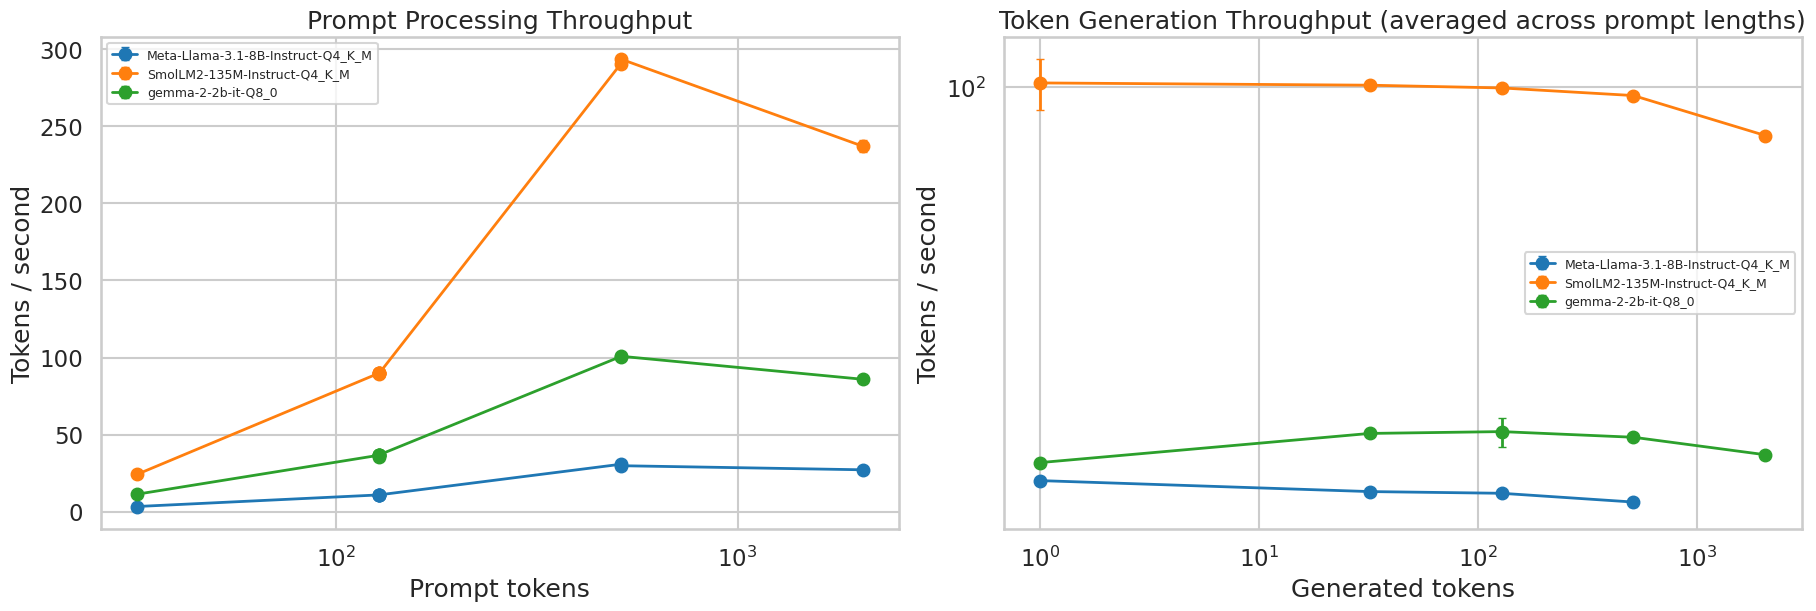

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
palette = sns.color_palette("tab10", n_colors=run_df['model'].nunique())
model_colors = {model: palette[i] for i, model in enumerate(sorted(run_df['model'].unique()))}

plot_48_df = run_df[run_df['threads'] == 48].copy()

prompt_df = plot_48_df.sort_values(["model", "prompt_tokens", "generation_tokens"])
for model, group in prompt_df.groupby("model"):
    axes[0].errorbar(
        group["prompt_tokens"],
        group["prompt_tps"],
        yerr=group["prompt_stddev"],
        marker="o",
        capsize=3,
        linewidth=2,
        label=model,
        color=model_colors[model],
    )
axes[0].set_xscale("log")
axes[0].set_title("Prompt Processing Throughput")
axes[0].set_xlabel("Prompt tokens")
axes[0].set_ylabel("Tokens / second")
axes[0].legend(fontsize=9)

# Aggregate generation throughput by generation_tokens (average over all prompt_lengths)
gen_agg = plot_48_df.groupby(['model', 'generation_tokens']).agg({
    'generation_tps': 'max',
    'generation_stddev': 'max'
}).reset_index()

for model, group in gen_agg.groupby("model"):
    group = group.sort_values('generation_tokens')
    axes[1].errorbar(
        group["generation_tokens"],
        group["generation_tps"],
        yerr=group["generation_stddev"],
        marker="o",
        capsize=3,
        linewidth=2,
        label=model,
        color=model_colors[model],
    )
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Token Generation Throughput (averaged across prompt lengths)")
axes[1].set_xlabel("Generated tokens")
axes[1].set_ylabel("Tokens / second")
axes[1].legend(fontsize=9)

plt.show()

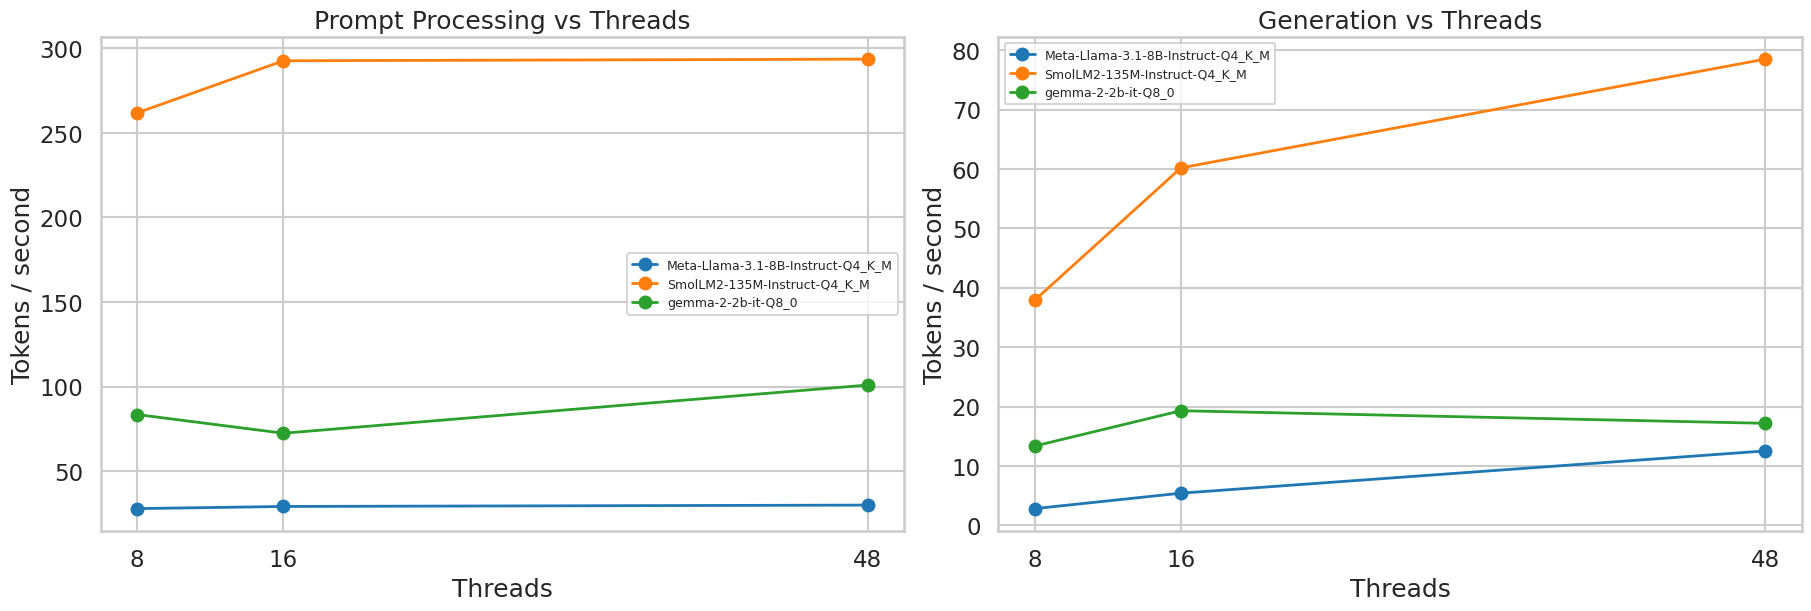

In [4]:
scale_df = run_df[(run_df['prompt_tokens'] == 512) & (run_df['generation_tokens'] == 128) & (run_df['threads'].isin([8, 16, 48]))].copy()
scale_df = scale_df.sort_values(['model', 'threads'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for model, group in scale_df.groupby('model'):
    axes[0].plot(group['threads'], group['prompt_tps'], marker='o', linewidth=2, label=model, color=model_colors[model])
    axes[1].plot(group['threads'], group['generation_tps'], marker='o', linewidth=2, label=model, color=model_colors[model])

axes[0].set_title('Prompt Processing vs Threads')
axes[0].set_xlabel('Threads')
axes[0].set_ylabel('Tokens / second')
axes[0].set_xticks([8, 16, 48])
axes[0].legend(fontsize=9)

axes[1].set_title('Generation vs Threads')
axes[1].set_xlabel('Threads')
axes[1].set_ylabel('Tokens / second')
axes[1].set_xticks([8, 16, 48])
axes[1].legend(fontsize=9)

plt.show()

                           model  run_index backend  threads quantization  \
10  SmolLM2-135M-Instruct-Q4_K_M          1    BLAS       48       Q4_K_M   
11  SmolLM2-135M-Instruct-Q4_K_M          2    BLAS       48       Q4_K_M   
12  SmolLM2-135M-Instruct-Q4_K_M          3    BLAS       48       Q4_K_M   
13  SmolLM2-135M-Instruct-Q4_K_M          4    BLAS       48       Q4_K_M   

    repeats  model_size_gib  model_size_mib  parameters_billions  \
10        3             NaN           98.87                  NaN   
11        3             NaN           98.87                  NaN   
12        3             NaN           98.87                  NaN   
13        3             NaN           98.87                  NaN   

    parameters_millions  prompt_tokens  prompt_tps  prompt_stddev  \
10               134.52             32       24.28           0.05   
11               134.52            128       89.88           0.12   
12               134.52            512      290.43           0.42 

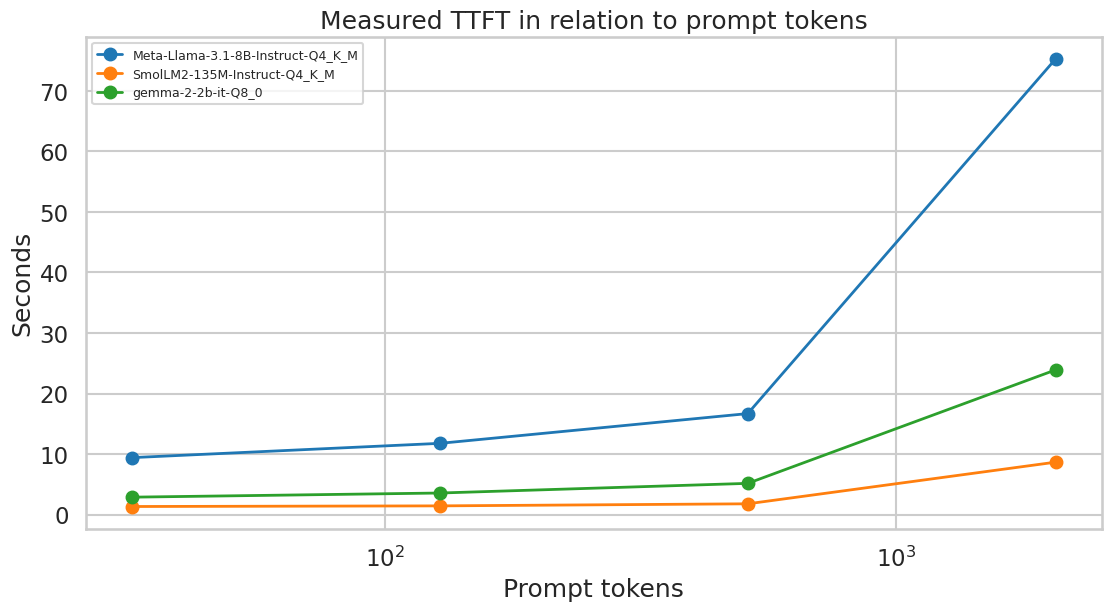

In [6]:
ttft_df = run_df[(run_df['threads'] == 48) & (run_df['generation_tokens'] == 1)].copy().sort_values(['model', 'prompt_tokens'])
print(ttft_df[ttft_df['model']=='SmolLM2-135M-Instruct-Q4_K_M'])
fig, ax = plt.subplots(figsize=(11, 6), constrained_layout=True)
for model, group in ttft_df.groupby('model'):
    ax.plot(
        group['prompt_tokens'],
        group['ttft_proxy_seconds'],
        marker='o',
        linewidth=2,
        label=model,
        color=model_colors[model],
    )

ax.set_xscale('log')
ax.set_title('Measured TTFT in relation to prompt tokens')
ax.set_xlabel('Prompt tokens')
ax.set_ylabel('Seconds')
ax.legend(fontsize=9)

plt.show()

## Notes

- The throughput and TTFT plots use only the 48-thread runs.
- The thread-scaling plot isolates the runs with 512 prompt tokens and 128 generation tokens, because those are the only entries measured at 8, 16, and 48 threads.
- The TTFT plot is a measured proxy derived from the prompt and single-token generation timings.